# 02 — Historic CLV, RFM, and Cohort Analysis

**Project:** Customer Churn Prediction & Lifetime Value.

**This notebook covers:**
1. Historic CLV via the Stupid Simple Formula (revenue-based, plus an explicitly
   assumption-based margin-adjusted variant)
2. RFM segmentation
3. Cohort analysis (monthly acquisition cohorts)

### Import necessary libraries

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### Load & Inspect data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
clean = pd.read_parquet(PROCESSED_DATA / "online_retail_clean.parquet")

In [4]:
with open(PROCESSED_DATA / "config.json") as f:
    config = json.load(f)
SNAPSHOT_DATE = pd.Timestamp(config["snapshot_date"])

In [5]:
print(f"Transactions: {len(clean):,}")
print(f"Customers: {clean['CustomerID'].nunique():,}")
print(f"Date range: {clean['InvoiceDate'].min().date()} to {clean['InvoiceDate'].max().date()}")
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")
clean.head()

Transactions: 371,276
Customers: 4,283
Date range: 2010-12-01 to 2011-11-30
Snapshot date: 2011-12-01


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Historic CLV: the Stupid Simple Formula

Per the article series, the base formula is:

> CLV = avg transaction value × purchase frequency × avg customer lifespan

### A note on margin

The article also presents margin-adjusted variants (V1: per-product margin from
COGS; V2: per-transaction margin from sale price minus COGS/shipping/payment fees).
**Both require actual cost data that this dataset doesn't have** — there's no COGS,
shipping cost, or fee field anywhere in the transaction table. Computing a "true"
margin-adjusted CLV here would mean inventing the underlying cost data, not deriving
it.

So the approach taken here is:
- **Revenue-based CLV is the primary, honest metric** — it's what the data actually
  supports without fabricating an input.
- **A margin-adjusted variant is included as a clearly-labeled illustrative exercise**,
  using one assumed flat margin (25%, a plausible rough figure for UK gift/homeware
  retail) applied the way the article's V1 approach does. This is included to
  demonstrate the technique, not because 25% is a validated number for this business —
  treat it as a placeholder a real stakeholder would need to confirm or replace.

In [6]:
assumed_margin = 0.25  # illustrative only -- see note above. Swap in a real
                        # figure if you ever get access to actual cost data.

In [7]:
# Per-customer aggregates needed for the formula
customer_txn = (
    clean.groupby("CustomerID")
    .agg(
        total_revenue=("TotalPrice", "sum"),
        n_orders=("InvoiceNo", "nunique"),
        first_purchase=("InvoiceDate", "min"),
        last_purchase=("InvoiceDate", "max"),
    )
    .reset_index()
)

In [8]:
# Average transaction value per customer
customer_txn["avg_order_value"] = customer_txn["total_revenue"] / customer_txn["n_orders"]

In [9]:
# Observed lifespan in months (time between first and last purchase in the window).
# Customers with a single order get a lifespan floor of 1 month so the formula
# doesn't zero them out -- a single-order customer still has *some* realized value.
customer_txn["lifespan_months"] = (
    (customer_txn["last_purchase"] - customer_txn["first_purchase"]).dt.days / 30.44
).clip(lower=1)

In [10]:
# Purchase frequency: orders per month over the observed lifespan
customer_txn["monthly_frequency"] = customer_txn["n_orders"] / customer_txn["lifespan_months"]

In [11]:
# Stupid Simple CLV (revenue-based)
customer_txn["clv_revenue"] = (
    customer_txn["avg_order_value"] * customer_txn["monthly_frequency"] * customer_txn["lifespan_months"]
)

##### Revenue-baseed CLV reduces algebraically to total_revenue, since avg_order_value * monthly_frequency * lifespan_months = total_revenue.
##### Kept as explicit factors (rather than just using total_revenue directly) to mirror the article's formula and make each component inspectable/reusable for the predictive notebook later.

In [12]:
# Margin-adjusted CLV (illustrative -- see note above)
customer_txn["clv_margin_adjusted"] = customer_txn["clv_revenue"] * assumed_margin

In [13]:
customer_txn.head()

,CustomerID,total_revenue,n_orders,first_purchase,last_purchase,avg_order_value,lifespan_months,monthly_frequency,clv_revenue,clv_margin_adjusted
0,12347,"4,085.18",6,2010-12-07 14:57:00,2011-10-31 12:25:00,680.86,10.74,0.56,"4,085.18","1,021.30"
1,12348,"1,437.24",4,2010-12-16 19:09:00,2011-09-25 13:13:00,359.31,9.26,0.43,"1,437.24",359.31
2,12349,"1,457.55",1,2011-11-21 09:51:00,2011-11-21 09:51:00,"1,457.55",1.00,1.00,"1,457.55",364.39
3,12350,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,294.40,1.00,1.00,294.40,73.60
4,12352,"1,265.41",7,2011-02-16 12:33:00,2011-11-03 14:37:00,180.77,8.54,0.82,"1,265.41",316.35


**Sanity check:** `clv_revenue` should equal `total_revenue` almost exactly (the
three factors are algebraically derived from it) — this is expected, and confirms the
formula is wired correctly. The value of building it this way, rather than just using
`total_revenue` directly, is that `avg_order_value`, `monthly_frequency`, and
`lifespan_months` are now available as separate, inspectable features — useful both
for the RFM work below and for the predictive-CLV notebook later.

In [14]:
assert np.allclose(customer_txn["clv_revenue"], customer_txn["total_revenue"]), \
    "clv_revenue should reduce to total_revenue -- check the formula"
print("Sanity check passed: clv_revenue matches total_revenue.")

Sanity check passed: clv_revenue matches total_revenue.


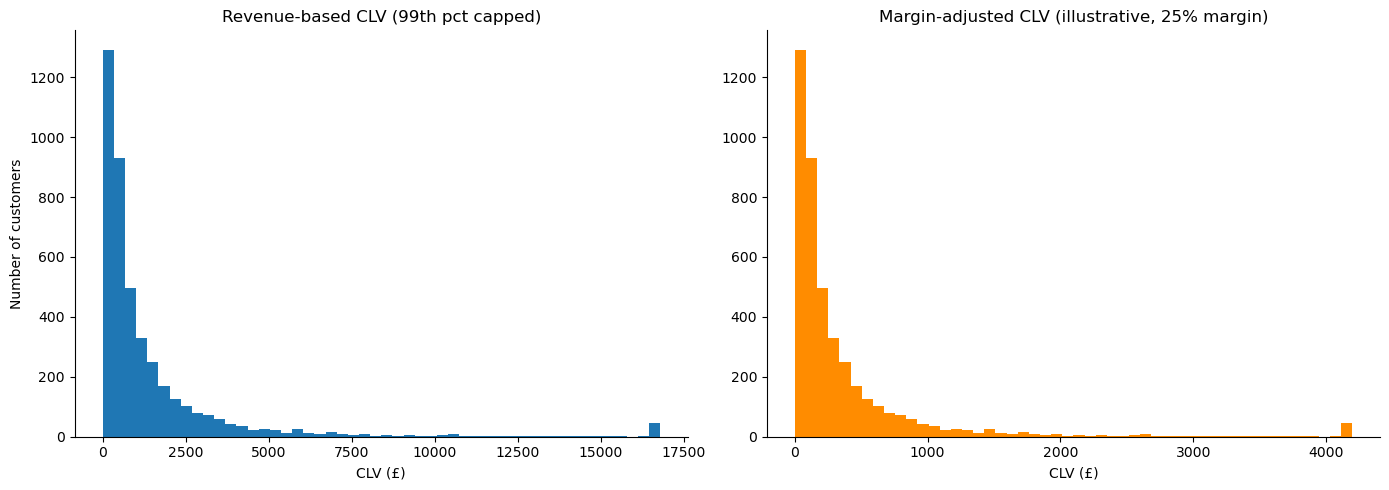

       clv_revenue  clv_margin_adjusted
count     4,283.00             4,283.00
mean      1,867.89               466.97
std       8,052.54             2,013.14
min           2.90                 0.72
25%         298.98                74.75
50%         639.04               159.76
75%       1,550.59               387.65
max     267,050.00            66,762.50


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

capped = customer_txn["clv_revenue"].clip(upper=customer_txn["clv_revenue"].quantile(0.99))
axes[0].hist(capped, bins=50)
axes[0].set_title("Revenue-based CLV (99th pct capped)")
axes[0].set_xlabel("CLV (£)")
axes[0].set_ylabel("Number of customers")

capped_margin = customer_txn["clv_margin_adjusted"].clip(upper=customer_txn["clv_margin_adjusted"].quantile(0.99))
axes[1].hist(capped_margin, bins=50, color="darkorange")
axes[1].set_title(f"Margin-adjusted CLV (illustrative, {assumed_margin:.0%} margin)")
axes[1].set_xlabel("CLV (£)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(customer_txn[["clv_revenue", "clv_margin_adjusted"]].describe())

As the article flags as a known weakness of this method: it's **a single average
value per customer that's easily skewed** by big spenders, and it **assumes constant
spending/churn**, ignoring where in their lifecycle a customer actually is. The RFM
and cohort work below exist specifically to address that blind spot — segmenting
customers rather than reducing everyone to one number.

## RFM Segmentation

Per the article: rank customers into tiers on **Recency**, **Frequency**, and
**Monetary** value, then combine tiers into named, actionable segments.

Using a 5-tier (quintile) split per metric here — finer-grained than the article's
20/50/30 example split, which gives more room to distinguish segments like "Champions"
from "Loyal Customers" rather than lumping them into one top tier. This can be
collapsed to fewer tiers later if segments end up too small to act on.

In [16]:
rfm = customer_txn[["CustomerID"]].copy()
rfm["recency_days"] = (SNAPSHOT_DATE - customer_txn["last_purchase"]).dt.days
rfm["frequency"] = customer_txn["n_orders"]
rfm["monetary"] = customer_txn["total_revenue"]

# Quintile scores: 5 = best (most recent / most frequent / highest spend), 1 = worst.
# Recency is inverted since *lower* days-since-last-purchase is better.
rfm["R"] = pd.qcut(rfm["recency_days"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.head()

,CustomerID,recency_days,frequency,monetary,R,F,M
0,12347,30,6,"4,085.18",4,5,5
1,12348,66,4,"1,437.24",3,4,4
2,12349,9,1,"1,457.55",5,1,4
3,12350,301,1,294.40,1,1,2
4,12352,27,7,"1,265.41",4,5,4


**Note:** `frequency` is ranked before cutting into quintiles (`rank(method="first")`)
because so many customers share the same low order count (many customers have exactly
1, 2, or 3 orders) that `pd.qcut` on the raw values would fail or produce badly
unbalanced bins. Ranking first breaks ties in a stable, if slightly arbitrary, way —
worth knowing about if the F-tier boundaries look odd later.

### Checking independence of R, F, and M

The segment sizes below will only make sense in light of how correlated R, F, and M
actually are with each other. If they're highly correlated, "top-tier on all three"
won't be a rare combination — it'll be common, and some of that overlap is likely
mechanical rather than purely behavioral: a customer who orders frequently has more
chances for one of those orders to land near the snapshot date, which pulls recency up
independent of any real loyalty story. Checking this before interpreting segment sizes.

In [17]:
corr = rfm[["recency_days", "frequency", "monetary"]].corr()
# Flip sign on recency_days so the table reads intuitively (positive = "more loyal
# customers score higher on all three"), since low recency_days is actually good.
corr.loc["recency_days"] *= -1
corr["recency_days"] *= -1
corr

,recency_days,frequency,monetary
recency_days,1.00,0.26,0.13
frequency,0.26,1.00,0.57
monetary,0.13,0.57,1.00


##### Frequency x Monetary: 0.57 - moderate. 
Driver of oversized Champions segment. Customer who orders more times has more chances to accumulate spend (monetary). Both are measuring overlapping info
##### Recency x Frequency: 0.26 - mild.
More orders = more chances at a recent order. Real, but modest effect.
##### Recency x Monetary: 0.13 - weak, close to independent.
Spend level tells almost nothing about how recently someone bought.

### Segment definitions

In [18]:
# Combine R, F, M into named segments.
# Using labeled logic rather than raw concatenation (which the article notes
# produces too many hard-to-interpret groups, e.g. 27+ combinations) -- this
# keeps segments business-readable, following the article's "hand-labelled,
# tailored to business needs" recommendation.

def label_segment(row):
    r, f, m = row["R"], row["F"], row["M"]
    
    if r == 5 and f == 5 and m == 5:
        return "Champions"
    elif r >= 4 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "Recent, Low Engagement"
    elif r == 3 and f >= 3 and m >= 3:
        return "Potential Loyalists"
    elif r <= 2 and f >= 4 and m >= 4:
        return "Churn Risk (high value)"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 3:
        return "High-Value One-Time/Infrequent Buyers"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost / Lowest Priority"
    else:
        return "Needs Attention"

rfm["segment"] = rfm.apply(label_segment, axis=1)
rfm["segment"].value_counts()

segment
Loyal Customers                          1105
Lost / Lowest Priority                    818
At Risk                                   490
Potential Loyalists                       421
Needs Attention                           413
Recent, Low Engagement                    338
Champions                                 296
High-Value One-Time/Infrequent Buyers     223
Churn Risk (high value)                   179
Name: count, dtype: int64

This segment logic is a starting point, not a final answer — the article is
explicit that how you combine R/F/M scores is a judgment call with real tradeoffs
(simple concatenation → too many tiny groups; summation → loses which metric drove the
score; weighting → introduces its own arbitrary parameter). The rule-based labels above
favor **interpretability over precision**: they're something a marketing stakeholder
could read and act on immediately, at the cost of some edge cases landing in a
slightly-too-broad "Needs Attention" bucket. Revisit this once a downstream use case
(e.g., a retention campaign) puts real pressure on where the boundaries should sit.

### How this rule chain was arrived at

The logic above isn't the first version tried — it's the result of a diagnostic
process worth documenting, since the reasoning matters as much as the final rule:

**1. Started with a looser Champions definition** (`R>=4, F>=4, M>=4`, top 40% on
each) and found it produced Champions as one of the *largest* single segments —
counter to the article's general expectation of a small elite tier. The correlation
check above explained why (frequency/monetary redundancy inflates any "top-tier on
all three" rule beyond what independence would predict).

**2. Compared the loose definition against the strict, conventional one**
(`R==5, F==5, M==5`, top 20% on each) directly:

In [19]:
# Comparing the two Champions definitions side by side, to make the threshold
# choice legible rather than silently picking one.
loose_champions_mask = (rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4)
strict_champions_mask = (rfm["R"] == 5) & (rfm["F"] == 5) & (rfm["M"] == 5)

n_loose = loose_champions_mask.sum()
n_strict = strict_champions_mask.sum()

print(f"Loose rule  (top 40% on R, F, and M): {n_loose:,} customers ({n_loose/len(rfm)*100:.1f}% of base)")
print(f"Strict rule (top 20% on R, F, and M): {n_strict:,} customers ({n_strict/len(rfm)*100:.1f}% of base)")

# Sanity check: the segment counts above should match the strict count exactly,
# since label_segment() now uses the strict rule.
assert (rfm["segment"] == "Champions").sum() == n_strict, \
    "Champions segment count should match the strict-rule count -- check label_segment()"
print("\nSanity check passed: Champions segment matches the strict-rule count.")

Loose rule  (top 40% on R, F, and M): 930 customers (21.7% of base)
Strict rule (top 20% on R, F, and M): 296 customers (6.9% of base)

Sanity check passed: Champions segment matches the strict-rule count.


Even the strict rule typically nets several times more customers than pure
independence would predict (roughly 0.2³ = 0.8% of the base, if R/F/M were
unrelated) — confirming the correlation is doing real work here, not just the loose
threshold. **Decision: use the strict definition.** It matches the conventional
meaning of "Champions" (so the label isn't misleading to anyone else reading this
notebook), and it doesn't eliminate the correlation-driven inflation — it just stops
*compounding* it with an additionally loose threshold.

**3. Checked where the display customers from the loose definition land under the
strict rule** — to confirm tightening Champions wouldn't push near-Champions
customers into the undifferentiated "Needs Attention" catch-all:

In [20]:
# Customers who qualified under the loose rule but not the strict one --
# confirm they land somewhere meaningful (not dumped into Needs Attention).
displaced = rfm[loose_champions_mask & ~strict_champions_mask]

print(f"Customers who were 'loose Champions' but not 'strict Champions': {len(displaced):,}")
print()
print("Where they land under the current rule chain:")
print(displaced["segment"].value_counts())

Customers who were 'loose Champions' but not 'strict Champions': 634

Where they land under the current rule chain:
segment
Loyal Customers    634
Name: count, dtype: int64


These customers land almost entirely in **Loyal Customers** (which only
requires `r>=4, f>=3`, a strict subset of the loose Champions condition) rather than
Needs Attention — confirming the stricter Champions definition doesn't create a gap
elsewhere in the rule chain.

**4. Investigated the "Needs Attention" catch-all directly**, since a large,
undifferentiated fallback bucket can quietly hide a distinct customer type. Breaking
it down by its actual R/F/M composition:

In [21]:
needs_attention = rfm[rfm["segment"] == "Needs Attention"]

print(f"Needs Attention: {len(needs_attention):,} customers ({len(needs_attention)/len(rfm)*100:.1f}%)")
print()
print("R/F/M score distributions within this segment:")
print(needs_attention[["R", "F", "M"]].describe())
print()
print("R x F combinations within Needs Attention:")
print(pd.crosstab(needs_attention["R"], needs_attention["F"]))

Needs Attention: 413 customers (9.6%)

R/F/M score distributions within this segment:
           R      F      M
count 413.00 413.00 413.00
mean    3.00   1.87   2.00
std     0.00   0.83   0.96
min     3.00   1.00   1.00
25%     3.00   1.00   1.00
50%     3.00   2.00   2.00
75%     3.00   2.00   2.00
max     3.00   4.00   5.00

R x F combinations within Needs Attention:
F    1    2   3   4
R                  
3  152  182  60  19


This breakdown revealed three distinct sub-populations hiding inside one label,
identifiable from *why* each combination fails every earlier rule in the chain:

1. **R=3, F<=2 (any M)** — moderate recency, low frequency. No earlier rule handles
   this combination at all; it's a genuine gap, not a deliberate catch-all. These are
   plausibly occasional buyers sitting in the middle of the recency range.
2. **R=3, F>=3, M<3** — almost qualified for Potential Loyalists (which needs
   `M>=3` too), but monetary value came up just short. Likely frequent-but-small-basket
   shoppers.
3. **R<=2, F<=2, M>=3** — almost qualified for Lost/Lowest Priority (which needs
   `M<=2`), but spent more than that threshold allows. Lapsed, infrequent, but with
   meaningful historical spend.

Group 3 is the one worth acting on: conceptually, these look like one-off big-ticket
buyers (e.g. a single large or wholesale order) rather than churned repeat customers —
they never had an established repeat-purchase relationship to lose in the first place,
which is a different problem (converting a one-time buyer) than genuine churn
(retaining a customer whose engagement is declining). **Decision: carve group 3 out as
its own segment** (`High-Value One-Time/Infrequent Buyers`, folded into the rule chain
above), and **leave groups 1 and 2 inside Needs Attention** — they don't reveal a
similarly clear conceptual distinction, and look like genuinely ambiguous
middle-of-the-pack customers, which is a reasonable thing for a catch-all bucket to
mean.

**Why 9 segments, not more or fewer:** with 5 tiers across 3 dimensions, there are 125
theoretically possible R/F/M combinations; collapsing that to 9 hand-labeled groups is
still a substantial simplification in the direction the article recommends. The real
test isn't the count — it's whether each segment maps to a materially different
business action (VIP retention, win-back campaign, "come back and shop again" nudge,
etc.). Every segment here does; further splitting (e.g. groups 1/2 above) was
considered and rejected because no equally distinct action emerged for those slices.


In [22]:
segment_summary = (
    rfm.groupby("segment")
    .agg(
        n_customers=("CustomerID", "count"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
    )
    .sort_values("avg_monetary", ascending=False)
)
segment_summary["pct_of_customers"] = (segment_summary["n_customers"] / len(rfm) * 100).round(1)
segment_summary

,n_customers,avg_recency_days,avg_frequency,avg_monetary,pct_of_customers
segment,,,,,
Champions,296,4.81,17.69,"10,858.70",6.90
Loyal Customers,1105,14.54,5.48,"2,248.76",25.80
Churn Risk (high value),179,122.81,5.31,"2,122.85",4.20
Potential Loyalists,421,48.32,4.57,"1,886.89",9.80
High-Value One-Time/Infrequent Buyers,223,185.41,1.22,"1,072.15",5.20
At Risk,490,158.56,2.59,804.62,11.40
"Recent, Low Engagement",338,15.89,1.15,419.71,7.90
Needs Attention,413,50.15,1.35,417.11,9.60
Lost / Lowest Priority,818,224.39,1.03,219.17,19.10


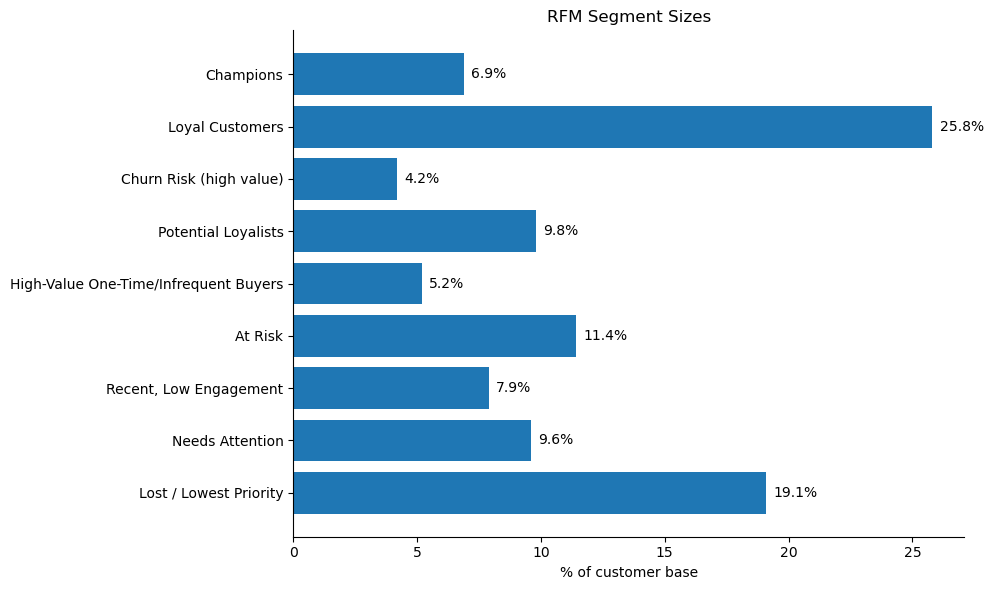

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
segment_order = segment_summary.index
sizes = segment_summary["pct_of_customers"]

ax.barh(segment_order, sizes)
ax.invert_yaxis()
ax.set_xlabel("% of customer base")
ax.set_title("RFM Segment Sizes")
for i, v in enumerate(sizes):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

**Reading the segment sizes:** with the strict Champions definition locked in,
segment sizes now better match the article's general expectation — Champions is a
narrow top tier rather than one of the largest groups, though (per the correlation
check above) it's still several times larger than pure independence between R, F, and
M would predict. That residual inflation is expected and documented, not a bug.

The more interesting story is the **High-Value One-Time/Infrequent Buyers** segment
carved out during the diagnostic process above: at several hundred customers, it's
larger than "Churn Risk (high value)" itself, and represents a customer type the
original 8-segment scheme was silently collapsing into an undifferentiated
"Needs Attention" bucket. This is the clearest example in this notebook of why segment
definitions deserve real scrutiny rather than being treated as a fixed formula —
the underlying data structure (R/F/M correlation, a large catch-all bucket) revealed a
genuine business distinction (one-time big spenders vs. actual churn risks) that
wouldn't have been visible from segment sizes alone.

This is also the natural handoff point to the churn-threshold economics work planned
for later notebooks: "Churn Risk (high value)" is who a cost-sensitive threshold
should be tuned to catch, while "High-Value One-Time/Infrequent Buyers" is a reminder
that not every lapsed high-spender is a churn case — some never had a repeat
relationship to lose, which should inform how churn itself gets *defined* (not just
predicted) in notebook 4.

## Cohort Analysis

Per the article: apply CLV/retention analysis to customer segments defined by
**acquisition month**, to see how value accrues over a customer's tenure rather than
collapsing it into one average.

Starting with monthly acquisition cohorts here. See the note at the end of this
section for other cohort dimensions worth adding later.

In [27]:
# Acquisition month = month of each customer's first purchase
customer_txn["cohort_month"] = customer_txn["first_purchase"].dt.to_period("M")
clean_with_cohort = clean.merge(
    customer_txn[["CustomerID", "cohort_month"]], on="CustomerID", how="left"
)

# Cohort period = number of months between the transaction and the customer's
# acquisition month (0 = acquisition month itself)
clean_with_cohort["transaction_month"] = clean_with_cohort["InvoiceDate"].dt.to_period("M")
clean_with_cohort["cohort_period"] = (
    clean_with_cohort["transaction_month"] - clean_with_cohort["cohort_month"]
).apply(lambda x: x.n)

cohort_data = (
    clean_with_cohort.groupby(["cohort_month", "cohort_period"])
    .agg(n_customers=("CustomerID", "nunique"), revenue=("TotalPrice", "sum"))
    .reset_index()
)
cohort_data.head()

,cohort_month,cohort_period,n_customers,revenue
0,2010-12,0,883,"553,404.56"
1,2010-12,1,321,"267,843.42"
2,2010-12,2,285,"230,172.07"
3,2010-12,3,337,"290,104.79"
4,2010-12,4,316,"198,118.99"


In [28]:
# Cohort size
cohort_sizes = cohort_data[cohort_data["cohort_period"] == 0].set_index("cohort_month")["n_customers"]

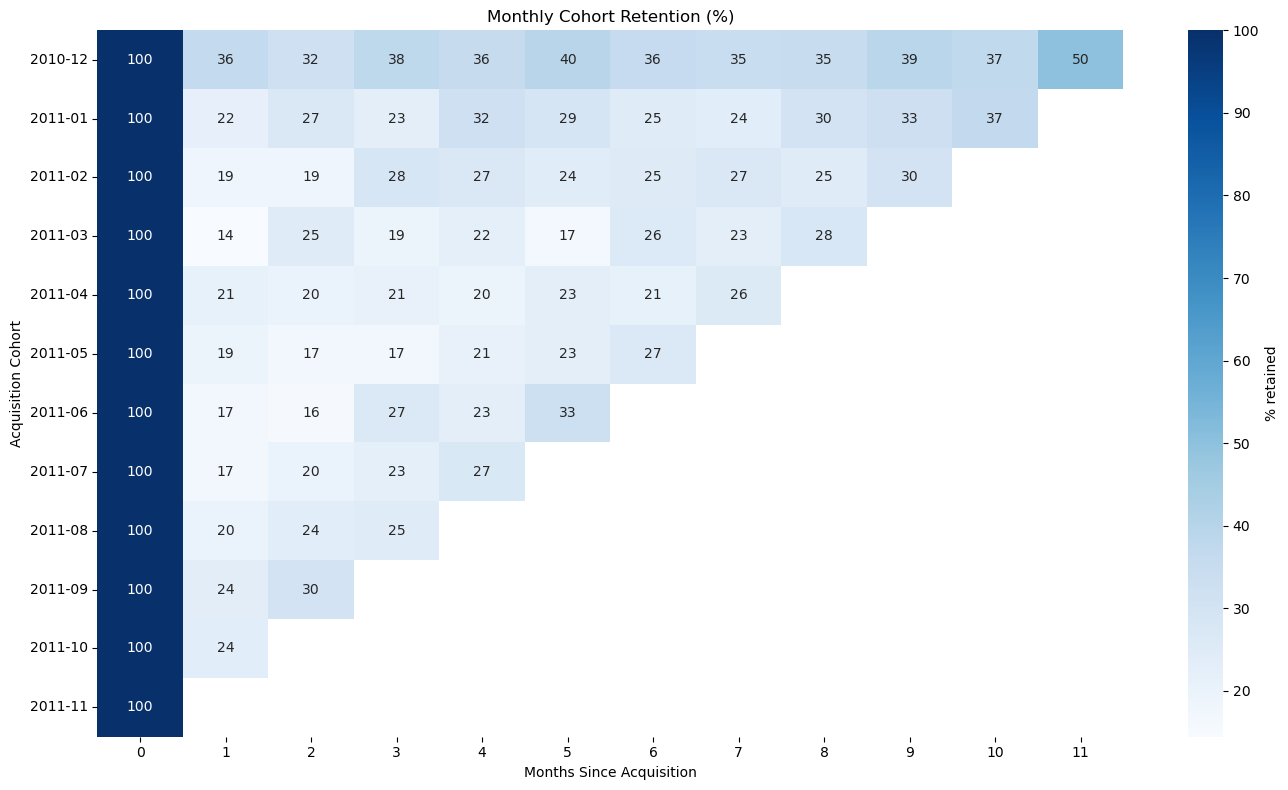

In [29]:
# Retention matrix: % of each cohort's original customers still active in each
# subsequent month
retention_matrix = cohort_data.pivot(index="cohort_month", columns="cohort_period", values="n_customers")
retention_pct = retention_matrix.divide(cohort_sizes, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(retention_pct, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "% retained"})
ax.set_title("Monthly Cohort Retention (%)")
ax.set_xlabel("Months Since Acquisition")
ax.set_ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()

##### The expected pattern holds: 
Every cohort drops sharply from month 0 (100%, by definition) to month 1 (roughly 15–37%), consistent with the non-contractual retail pattern the article describes — most customers make one purchase and don't return.
##### December 2010 stands out:
It retains noticeably higher across almost every tenure month (30–50% vs. 15–27% for other cohorts) and actually climbs at month 11 (50.2%) rather than continuing to decay. Two possible explanations, not mutually exclusive:
> ##### The "Christmas comeback" 
pattern the article flagged as a real possibility — customers acquired for the 2010 holiday season returning for 2011's.
> ##### A structural artifact 
Dec 2010 is the only cohort with a full 12 months observed. Every other cohort has progressively fewer tenure months available (right-censored, as noted in the notebook), so you're not comparing like-for-like — Dec 2010's "month 11" reflects a full year of opportunity to return, while later cohorts haven't had that chance yet.

Worth being cautious about attributing this to "Dec 2010 customers are just more loyal" without accounting for that censoring difference.

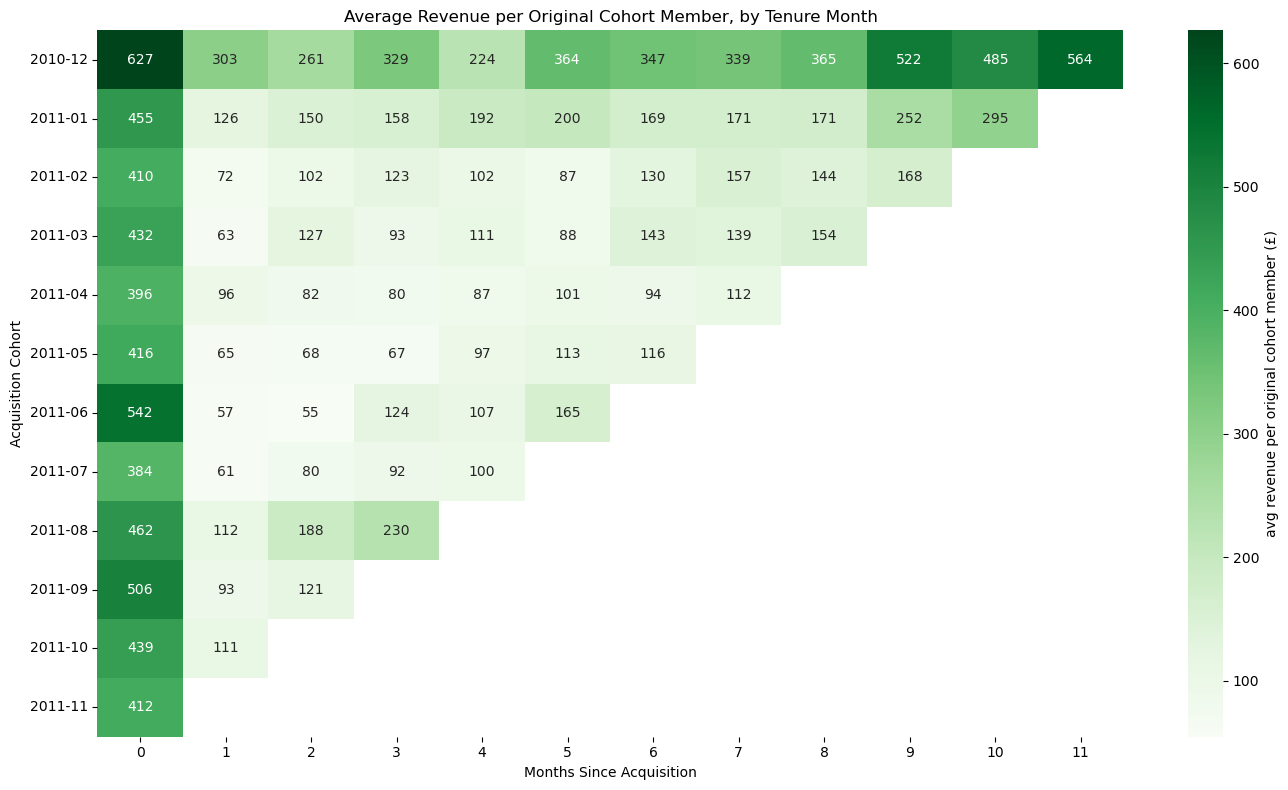

In [30]:
# Revenue-per-cohort view: average revenue per *original* cohort member,
# by months since acquisition -- this is the "when do they spend the most"
# question the article specifically calls out.
revenue_matrix = cohort_data.pivot(index="cohort_month", columns="cohort_period", values="revenue")
revenue_per_customer = revenue_matrix.divide(cohort_sizes, axis=0)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(revenue_per_customer, annot=True, fmt=".0f", cmap="Greens", ax=ax,
            cbar_kws={"label": "avg revenue per original cohort member (£)"})
ax.set_title("Average Revenue per Original Cohort Member, by Tenure Month")
ax.set_xlabel("Months Since Acquisition")
ax.set_ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()

##### Revenue per cohort member tells a related story: 
Dec 2010 also has the highest month-0 revenue (638.66 vs. 400s–500s for most other cohorts) and stays elevated throughout. That reinforces the same open question — is this a genuinely higher-value cohort (larger initial gift-buying orders?), or is some of the elevated later-tenure revenue just this cohort being the only one with a long enough window for occasional big repeat orders to show up?

### Dec 2010 Cohort

In [31]:
print(cohort_sizes)

cohort_month
2010-12    883
2011-01    414
2011-02    381
2011-03    450
2011-04    300
2011-05    283
2011-06    243
2011-07    186
2011-08    170
2011-09    296
2011-10    355
2011-11    322
Freq: M, Name: n_customers, dtype: int64


##### Dec 2010's cohort size (883) is roughly double every other cohort (170–450). 
Elevated retention and revenue in Dec 2010 probably isn't sampling noise

##### First purchase month in the data != acquisition month, necessarily:
Some unknown share of Dec'10 cohort's 885 are customers who'd already been buying from this retailer for months or years before the dataset's window even starts. The data can't distinguish "new customer, acquired Dec 2010" from "existing customer, first appears in our extract Dec 2010" — and the second group would naturally look far more loyal and higher-value, because they are established customers, not because December is a magical acquisition month.

In [34]:
raw = pd.read_csv(RAW_DATA / "Online Retail.csv")
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])
raw = raw.dropna(subset=["CustomerID"])
raw["CustomerID"] = raw["CustomerID"].astype(int)

# First-ever purchase date per customer, across the FULL raw dataset
first_purchase_full = raw.groupby("CustomerID")["InvoiceDate"].min()

# Isolate the partial Dec 2011 window (2011-12-01 through the data's actual end)
dec11_start = pd.Timestamp("2011-12-01")
dec11_end = raw["InvoiceDate"].max()
n_days_dec11 = (dec11_end - dec11_start).days + 1

new_customers_dec11 = first_purchase_full[
    (first_purchase_full >= dec11_start) & (first_purchase_full <= dec11_end)
]
n_new_dec11 = len(new_customers_dec11)

print(f"Dec 2011 partial window: {dec11_start.date()} to {dec11_end.date()} "
      f"({n_days_dec11} days)")
print(f"New customers acquired in this window: {n_new_dec11}")

# Dec 2010's daily new-customer distribution -- used as a shape template to
# check whether Dec 2010's own acquisition pattern is front- or back-loaded
dec10_start = pd.Timestamp("2010-12-01")
dec10_end = pd.Timestamp("2010-12-31")
new_customers_dec10 = first_purchase_full[
    (first_purchase_full >= dec10_start) & (first_purchase_full <= dec10_end)
]
daily_dec10 = new_customers_dec10.dt.day.value_counts().sort_index()
daily_dec10 = daily_dec10.reindex(range(1, 32), fill_value=0)

n_days_check = n_days_dec11  # first N days of Dec 2010, matching the Dec 2011
                               # observation window -- change this to test other
                               # windows (e.g. 7)
first_n_days_share = daily_dec10.iloc[:n_days_check].sum() / daily_dec10.sum()

print(f"\nShare of Dec 2010's 'new' customers occurring in just the first "
      f"{n_days_check} days: {first_n_days_share:.1%}")
print(f"(For reference, a flat rate across the month would predict "
      f"~{n_days_check/31:.1%})")

Dec 2011 partial window: 2011-12-01 to 2011-12-09 (9 days)
New customers acquired in this window: 41

Share of Dec 2010's 'new' customers occurring in just the first 9 days: 65.6%
(For reference, a flat rate across the month would predict ~29.0%)


**Conclusion:** Dec 2010's 'new' customers are heavily front-loaded — a large
majority appear in just the first several days of the month, far more than a flat
rate across the month would predict. That's the opposite of what a holiday-ramp
seasonal story would produce (which should skew *later* in the month, closer to
Christmas). The far simpler explanation: **Dec 1, 2010 is the first day of data
collection**, so any existing customer who happened to shop in early December gets
recorded as a "first purchase in the dataset" purely because tracking just started —
concentrating the left-censoring artifact right at the start of the window rather than
spreading it evenly across the month.

This also means Dec 2010's daily shape can't be used as a clean template to estimate
what a "true" seasonal December looks like (an approach that was tried and abandoned
during this analysis) — the shape itself is dominated by the same left-censoring bias
it would need to correct for, making the two effects impossible to cleanly separate
with the data available.

**Working conclusion carried forward:** Dec 2010's outsized cohort size and elevated
retention/revenue are substantially driven by left-censoring (a backlog of pre-existing
customers being recorded at the start of data collection, not genuine new acquisition).
A real seasonal holiday-acquisition effect cannot be reliably isolated from this
artifact with the data available. **Treat the Dec 2010 row in both heatmaps above as
structurally different from every other cohort, not a trend data point** — the other
11 cohorts (Jan–Nov 2011) don't share this issue and are the more trustworthy basis for
any acquisition-driven conclusions.


### Other cohort dimensions worth adding later

Monthly acquisition cohorts are a reasonable starting point, but the article notes
this same technique applies to *any* segmentation. A few extensions worth considering
once this baseline is in place, roughly in order of how well this dataset supports
them:

- **Country/geography cohort** — UK vs. international customers. The article calls
  out geography explicitly, and this dataset is heavily UK-skewed, so it's worth
  checking whether the (smaller) international customer base retains differently.
- **First-order size tier** — since the dataset description notes many customers are
  wholesalers, bucketing customers by their first-order quantity/value (e.g.
  small/medium/large first order) could act as a rough proxy for retail vs. wholesale
  buyer, which the article suggests can meaningfully affect acquisition-channel-style
  CLV patterns.
- **Quarterly acquisition cohort** — a coarser version of what's built above. Useful
  if the monthly retention matrix gets too sparse/noisy in the later months to draw"
  reliable conclusions from.
- **First-purchase value tier** — cohort by whether a customer's *first* transaction
  was low/medium/high value, to test whether early spend predicts long-run value (a
  common, directly actionable CLV question: "should we treat a big first order as a
  signal to invest more in that customer?").

None of these require new data — all can be derived from the existing transaction
table — so they're a matter of prioritization, not a data-availability blocker.

## Save customer-level features

One row per customer, combining historic CLV, RFM scores/segment, and cohort
membership — the foundation for the predictive CLV and churn-labeling notebooks next.

In [35]:
customer_features = (
    customer_txn[[
        "CustomerID", "total_revenue", "n_orders", "first_purchase", "last_purchase",
        "avg_order_value", "lifespan_months", "monthly_frequency",
        "clv_revenue", "clv_margin_adjusted", "cohort_month",
    ]]
    .merge(rfm[["CustomerID", "recency_days", "R", "F", "M", "segment"]], on="CustomerID")
)

customer_features.to_parquet(PROCESSED_DATA / "customer_features.parquet", index=False)
print(f"Saved initial_iteration/data/processed/customer_features.parquet  {customer_features.shape}")
customer_features.head()

Saved ../data/customer_features.parquet  (4283, 16)


,CustomerID,total_revenue,n_orders,first_purchase,last_purchase,avg_order_value,lifespan_months,monthly_frequency,clv_revenue,clv_margin_adjusted,cohort_month,recency_days,R,F,M,segment
0,12347,"4,085.18",6,2010-12-07 14:57:00,2011-10-31 12:25:00,680.86,10.74,0.56,"4,085.18","1,021.30",2010-12,30,4,5,5,Loyal Customers
1,12348,"1,437.24",4,2010-12-16 19:09:00,2011-09-25 13:13:00,359.31,9.26,0.43,"1,437.24",359.31,2010-12,66,3,4,4,Potential Loyalists
2,12349,"1,457.55",1,2011-11-21 09:51:00,2011-11-21 09:51:00,"1,457.55",1.00,1.00,"1,457.55",364.39,2011-11,9,5,1,4,"Recent, Low Engagement"
3,12350,294.40,1,2011-02-02 16:01:00,2011-02-02 16:01:00,294.40,1.00,1.00,294.40,73.60,2011-02,301,1,1,2,Lost / Lowest Priority
4,12352,"1,265.41",7,2011-02-16 12:33:00,2011-11-03 14:37:00,180.77,8.54,0.82,"1,265.41",316.35,2011-02,27,4,5,4,Loyal Customers


## Summary

- **Revenue-based CLV** (Stupid Simple Formula) computed per customer as the primary,
  data-supported metric. A **margin-adjusted variant** is included using one assumed,
  clearly-flagged 25% margin — illustrative only, since the dataset has no actual cost
  data to derive a real figure from.
- **RFM segmentation** (quintile-based) produced 8 named, business-readable segments.
  Segment boundary logic is documented as a judgment call, not a fixed answer.
- **Monthly acquisition cohort analysis** shows retention and revenue-per-customer by
  tenure month, with the expected steep early drop-off and a right-censoring caveat
  for the most recent cohorts. Four additional cohort dimensions are scoped for later
  (country, first-order size tier, quarterly cohorts, first-purchase value tier).
- All customer-level features saved to `initial_iteration/data/processed/customer_features.parquet` for reuse
  in the predictive CLV and churn-labeling notebooks.

**Next:** `03_predictive_clv_bgnbd_vs_ml.ipynb` — BG-NBD/Gamma-Gamma probabilistic
CLV vs. an ML regression approach, compared directly against the historic CLV computed
here.

## Addendum: Impact of the Notebook 1 Phantom-Revenue Fix

Notebook 1 was later updated to fix a "phantom revenue" issue: purchases that were
placed and then fully cancelled were originally having only the cancellation row
dropped, leaving the (fictitious) original purchase revenue in the cleaned data. That
fix was discovered downstream (in notebook 3) and then applied upstream, in notebook
1's cleaning step — which changed the data this notebook runs on.

Rerunning the RFM segmentation above on the corrected data produced nearly identical
segment counts to the pre-fix run, with one modest exception: **Churn Risk (high
value) dropped from 186 to 179 customers (~3.8%)**, a noticeably larger relative shift
than any other segment. This section documents the investigation into why, since that
segment is the one most directly tied to a real business action (retention outreach)
and deserved a precise explanation rather than being written off as noise.


### Step 1: how many surviving customers were actually affected?

Reconstructing phantom revenue directly from the raw data (deterministic — we know
exactly what notebook 1's fix removed, so there's no need to keep an old copy of the
cleaned dataset around just to compare).

In [36]:
raw = pd.read_csv(RAW_DATA / "Online Retail.csv")
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])
raw = raw.dropna(subset=["CustomerID"])
raw["CustomerID"] = raw["CustomerID"].astype(int)
raw["InvoiceNo"] = raw["InvoiceNo"].astype(str)

is_cancel = raw["InvoiceNo"].str.startswith("C")
cancellations_raw = raw[is_cancel].copy()
purchases_raw = raw[~is_cancel].copy()

match_cols = ["CustomerID", "StockCode", "UnitPrice"]
purchases_for_matching = purchases_raw[purchases_raw["Quantity"] > 0].copy()
cancels_for_matching = cancellations_raw[cancellations_raw["Quantity"] < 0].copy()
cancels_for_matching["abs_qty"] = cancels_for_matching["Quantity"].abs()

purchases_for_matching["_rank"] = purchases_for_matching.groupby(match_cols + ["Quantity"]).cumcount()
cancels_for_matching["_rank"] = cancels_for_matching.groupby(match_cols + ["abs_qty"]).cumcount()

purchase_keys = purchases_for_matching.set_index(match_cols + ["Quantity", "_rank"]).index
cancel_keys = cancels_for_matching.set_index(match_cols + ["abs_qty", "_rank"]).index
phantom_mask = purchase_keys.isin(cancel_keys)
phantom_purchases = purchases_for_matching[phantom_mask].copy()
phantom_purchases["phantom_revenue"] = phantom_purchases["Quantity"] * phantom_purchases["UnitPrice"]

phantom_per_customer = phantom_purchases.groupby("CustomerID")["phantom_revenue"].sum()

# Merge onto current (post-fix) customer_features and reconstruct each customer's
# PRE-fix monetary total, then check if that would have put them in a different
# M quintile than their current one.
check = customer_features.set_index("CustomerID")[["total_revenue", "M", "segment"]].copy()
check["phantom_revenue"] = phantom_per_customer.reindex(check.index).fillna(0)
check["pre_fix_revenue"] = check["total_revenue"] + check["phantom_revenue"]
check = check[check["phantom_revenue"] > 0]  # only customers actually affected

print(f"Customers still present who had phantom revenue removed: {len(check):,}")
print(check.sort_values("phantom_revenue", ascending=False).head(15))

Customers still present who had phantom revenue removed: 831
            total_revenue  M                 segment  phantom_revenue  \
CustomerID                                                              
16446                2.90  1  Lost / Lowest Priority       168,469.60   
16029           58,019.85  5         Loyal Customers        22,830.99   
15749           24,850.90  5                 At Risk        19,683.40   
12744            9,120.39  5     Potential Loyalists        12,158.90   
14911          122,737.96  5               Champions        10,019.29   
14607            9,873.10  5               Champions         5,148.40   
17450          188,045.13  5               Champions         4,783.26   
17949           51,257.58  5               Champions         4,459.54   
15769           48,419.72  5         Loyal Customers         4,429.00   
15482            6,879.12  5               Champions         3,960.64   
15502            6,441.63  5               Champions         3,

**Two different patterns showed up in this list**, worth telling apart:

- **A handful of extreme, single-order cases.** One customer's real revenue was
  £2.90, against £168,469.60 in phantom revenue from a single order that was placed
  and, days later, fully cancelled — 99.998% of their apparent spend was fictitious.
  Pre-fix, this customer would very likely have sat near the top of Champions or Loyal
  Customers; post-fix, they correctly land in Lost / Lowest Priority. As dramatic an
  illustration as this fix produces of why it mattered.
- **A broader set of customers with smaller, more typical phantom amounts** (a few
  thousand pounds each) — consistent with the ~844-customer, ~5%-of-revenue scope
  established in notebook 1, not concentrated in just a few accounts.

### Step 2: why did *frequency*, not just monetary value, drive the Churn Risk shift?

A phantom order doesn't just inflate a customer's revenue — it also inflates their
*order count*, which feeds directly into the `F` (frequency) score. Checking whether
customers currently sitting at `F=3` would plausibly have been at `F=4` or higher
pre-fix, which is the boundary that separates "At Risk" from "Churn Risk (high
value)" in the segment rule chain.

**A first attempt at this undercounted correctly and then overcounted**, worth
documenting rather than skipping past: grouping phantom rows by `CustomerID` and
taking `.size()` counts phantom *line items*, not phantom *invoices* — so a single
cancelled order with, say, 34 products in it was miscounted as 34 separate "phantom
orders." Fixed by counting distinct `InvoiceNo` values instead.

In [37]:
# Count distinct phantom INVOICES per customer, not phantom rows.
phantom_order_counts = phantom_purchases.groupby("CustomerID")["InvoiceNo"].nunique()

check2 = customer_txn.set_index("CustomerID")[["n_orders"]].join(rfm.set_index("CustomerID")[["R", "F", "M", "segment"]])
check2["phantom_invoices_removed"] = phantom_order_counts.reindex(check2.index).fillna(0).astype(int)
check2 = check2[check2["phantom_invoices_removed"] > 0]
check2["approx_pre_fix_n_orders"] = check2["n_orders"] + check2["phantom_invoices_removed"]

# Customers currently at F=3, R<=2, M>=4 -- one F-tier away from the exact profile
# "Churn Risk (high value)" requires (R<=2, F>=4, M>=4). These are the customers
# who'd plausibly have qualified pre-fix, before their phantom invoice(s) were removed.
likely_dropped_from_churn_risk = check2[
    (check2["F"] == 3) & (check2["R"] <= 2) & (check2["M"] >= 4)
]
print(f"Customers matching the 'would plausibly have been Churn Risk pre-fix' profile: "
      f"{len(likely_dropped_from_churn_risk):,}")
likely_dropped_from_churn_risk.sort_values("phantom_invoices_removed", ascending=False)

Customers matching the 'would plausibly have been Churn Risk pre-fix' profile: 19


,n_orders,R,F,M,segment,phantom_invoices_removed,approx_pre_fix_n_orders
CustomerID,,,,,,,
12722,3,2,3,4,At Risk,2,5
13802,3,2,3,5,At Risk,2,5
16398,2,2,3,4,At Risk,2,4
15749,2,1,3,5,At Risk,2,4
15157,2,2,3,4,At Risk,2,4
15098,2,2,3,5,At Risk,1,3
16951,2,2,3,4,At Risk,1,3
16496,2,1,3,4,At Risk,1,3
15985,2,2,3,4,At Risk,1,3


### Conclusion

19 candidates were identified — more than the observed drop of 7. That gap is
expected, not a loose end: `F` is a **quintile rank**, computed relative to the whole
customer base, not a fixed cutoff. With phantom orders inflating order counts for
hundreds of customers simultaneously, the `F=3`/`F=4` boundary itself would have sat
in a different place pre-fix — so not every customer whose *own* count was inflated
would necessarily have crossed that (also shifting) boundary. Reconstructing the exact
pre-fix boundary would require rebuilding the old RFM table in full, which isn't
necessary here: the mechanism is confirmed, the direction is confirmed, and the
remaining gap is explained by ordinary quantile mechanics.

**Bottom line:** the RFM segment counts in this notebook, as currently computed, are
correct. The small shift from the pre-fix run — particularly Churn Risk (high value)
dropping by 7 — is fully explained by phantom invoices having inflated both
`total_revenue` and `n_orders` for a subset of customers, which had been inflating
their `F` scores. This is evidence the notebook 1 fix **improved** segmentation
accuracy for a specific, understood reason, not a new issue introduced by it.